In [1]:
import slangpy as spy
import pathlib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = spy.create_device(
    include_paths=[
        pathlib.Path(".").absolute()
    ]
)

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


In [3]:
module = spy.Module.load_from_file(device, "slang/buffer-add.slang")
module

slangpy.Module("slang/buffer-add.slang", path="/Users/fangjun/Documents/stanford/gslang/notebooks/playgrounds/slang/buffer-add.slang")

In [4]:
image_a = spy.NDBuffer(device, dtype=module.Pixel, shape=(16, 16))
image_b = spy.NDBuffer(device, dtype=module.Pixel, shape=(16, 16))
image_a.shape, image_b.shape

([16, 16], [16, 16])

In [5]:
cursor_a = image_a.cursor()
for i in range(16):
    for j in range(16):
        cursor_a[i + j * 16].write({
            "r": (i + j) / 32 * 0.75,
            "g": 0,
            "b": 0
        })
cursor_a.apply()
# Populate the second buffer directly from a NumPy array
image_b.copy_from_numpy(0.25 * np.random.rand(16 * 16 * 3).astype(np.float32))

In [6]:
# Call the module's add function
result = module.add(image_a, image_b)

In [7]:
# Convert to rgba8_uint.
result = module.toColor(result)

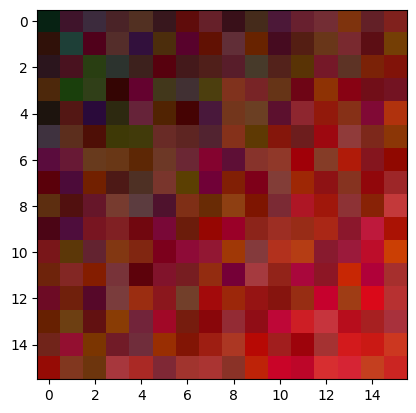

In [8]:
tex = device.create_texture(
    data=result.to_numpy(),
    width=16,
    height=16,
    format=spy.Format.rgba8_uint
)
plt.imshow(tex.to_numpy())